# Tongji EV Battery Dataset

### Chemistry: NMC (Nickel Manganese Cobalt)

**Institution:** Tongji University

**Objective:** State of Charge (SOC) Estimation using LSTM and GRU Networks

---

## Introduction

Accurate estimation of Battery State of Charge (SOC) is a fundamental requirement for Battery Management Systems (BMS) used in electric vehicles. Reliable SOC estimation improves battery safety, energy utilization, driving range prediction, and overall battery performance.

The Tongji EV Battery Dataset is a large-scale battery dataset containing operational measurements collected from Nickel Manganese Cobalt (NMC) lithium-ion batteries under various charging and discharging conditions. Due to its realistic battery behavior and diverse operating profiles, the dataset has become an important benchmark for data-driven battery modeling and SOC estimation research.

In this study, deep learning approaches are employed to estimate SOC using battery measurement data. Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) networks are utilized to capture the temporal characteristics of battery behavior and predict SOC from sequential battery measurements.

---

## Dataset Information

| Attribute | Description |
|------------|------------|
| Dataset | Tongji EV Battery Dataset |
| Chemistry | NMC (Nickel Manganese Cobalt) |
| Application | Electric Vehicle Battery Analysis |
| Inputs | Voltage, Current, Temperature |
| Target | State of Charge (SOC) |
| Models | LSTM, GRU |

---

## Workflow

1. Dataset Loading and Inspection
2. Data Preprocessing
3. Feature Selection
4. SOC Analysis
5. Data Normalization
6. Sequence Generation
7. Train-Test Split
8. LSTM Model Training
9. GRU Model Training
10. Performance Evaluation
11. Comparative Analysis

---

## Expected Outcome

The objective of this study is to evaluate the effectiveness of LSTM and GRU architectures for SOC estimation on NMC battery chemistry and compare the obtained results with previous experiments conducted on NCA, LFP, and NASA lithium-ion battery datasets.

#### Dataset Extraction

The Tongji EV Battery Dataset was downloaded and extracted for inspection. The dataset is expected to contain battery measurements collected from NMC lithium-ion cells under various operating conditions.

The extracted files will be analyzed to identify battery measurements, available features, and SOC information required for deep learning based SOC estimation.

In [16]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
import requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

In [1]:
import zipfile

zip_path = r"C:\Users\shrij\Downloads\Tongji.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(r"C:\Tongji")

print("Tongji Extracted Successfully!")

Tongji Extracted Successfully!


In [2]:
import os

count = 0

for root, dirs, files in os.walk(r"C:\Tongji"):

    for file in files:

        print(os.path.join(root, file))

        count += 1

        if count >= 50:
            break

    if count >= 50:
        break

C:\Tongji\Tongji\Tongji1_CY25-025_1--1.pkl
C:\Tongji\Tongji\Tongji1_CY25-025_1--2.pkl
C:\Tongji\Tongji\Tongji1_CY25-025_1--3.pkl
C:\Tongji\Tongji\Tongji1_CY25-025_1--4.pkl
C:\Tongji\Tongji\Tongji1_CY25-025_1--5.pkl
C:\Tongji\Tongji\Tongji1_CY25-025_1--6.pkl
C:\Tongji\Tongji\Tongji1_CY25-025_1--7.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--1.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--10.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--11.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--12.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--13.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--14.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--15.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--16.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--17.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--18.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--19.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--2.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--3.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--4.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--5.pkl
C:\Tongji\Tongji\Tongji1_CY25-05_1--6.pkl
C:\Tongji\Tongji\

## Dataset Structure Inspection

The Tongji EV Battery Dataset is stored in Python pickle (.pkl) format.

Each file contains battery measurements collected under different operating conditions. The internal structure of the dataset will be inspected to identify available features and SOC information required for model development.

In [3]:
import pickle

with open(
    r"C:\Tongji\Tongji\Tongji1_CY25-025_1--1.pkl",
    "rb"
) as f:

    data = pickle.load(f)

print(type(data))

<class 'dict'>


In [4]:
print(data.keys())

dict_keys(['cell_id', 'cycle_data', 'form_factor', 'anode_material', 'cathode_material', 'electrolyte_material', 'nominal_capacity_in_Ah', 'depth_of_charge', 'depth_of_discharge', 'already_spent_cycles', 'max_voltage_limit_in_V', 'min_voltage_limit_in_V', 'max_current_limit_in_A', 'min_current_limit_in_A', 'reference', 'description', 'charge_protocol', 'discharge_protocol', 'SOC_interval'])


In [5]:
for key in data.keys():
    print(key)
    print(type(data[key]))

cell_id
<class 'str'>
cycle_data
<class 'list'>
form_factor
<class 'str'>
anode_material
<class 'str'>
cathode_material
<class 'str'>
electrolyte_material
<class 'NoneType'>
nominal_capacity_in_Ah
<class 'float'>
depth_of_charge
<class 'float'>
depth_of_discharge
<class 'float'>
already_spent_cycles
<class 'int'>
max_voltage_limit_in_V
<class 'float'>
min_voltage_limit_in_V
<class 'float'>
max_current_limit_in_A
<class 'NoneType'>
min_current_limit_in_A
<class 'NoneType'>
reference
<class 'NoneType'>
description
<class 'NoneType'>
charge_protocol
<class 'list'>
discharge_protocol
<class 'list'>
SOC_interval
<class 'list'>


#### Cycle Data Exploration

The Tongji dataset contains battery metadata and operational measurements stored within the cycle_data field.

The cycle_data field contains time-series battery measurements collected during charging and discharging operations. These measurements will be inspected to identify Voltage, Current, Temperature, and SOC information required for deep learning based SOC estimation.

In [6]:
cycle = data['cycle_data'][0]

print(type(cycle))

try:
    print(cycle.keys())
except:
    pass

<class 'dict'>
dict_keys(['cycle_number', 'current_in_A', 'voltage_in_V', 'charge_capacity_in_Ah', 'discharge_capacity_in_Ah', 'time_in_s', 'temperature_in_C', 'internal_resistance_in_ohm'])


In [7]:
cycle = data['cycle_data'][0]

if isinstance(cycle, dict):

    print(cycle.keys())

dict_keys(['cycle_number', 'current_in_A', 'voltage_in_V', 'charge_capacity_in_Ah', 'discharge_capacity_in_Ah', 'time_in_s', 'temperature_in_C', 'internal_resistance_in_ohm'])


#### Feature Analysis

Inspection of the cycle data revealed the availability of voltage, current, temperature, capacity, and time measurements.

These measurements provide the necessary information required for constructing a deep learning based SOC estimation framework. Further analysis is performed to determine whether SOC values are directly available or need to be calculated from capacity information.

In [8]:
cycle = data['cycle_data'][0]

for key in cycle.keys():

    try:
        print(
            key,
            type(cycle[key]),
            len(cycle[key])
        )

    except:
        print(
            key,
            type(cycle[key])
        )

cycle_number <class 'int'>
current_in_A <class 'list'> 1867
voltage_in_V <class 'list'> 1867
charge_capacity_in_Ah <class 'list'> 1867
discharge_capacity_in_Ah <class 'list'> 1867
time_in_s <class 'list'> 1867
temperature_in_C <class 'NoneType'>
internal_resistance_in_ohm <class 'NoneType'>


In [12]:
cycle = data['cycle_data'][0]

print("Voltage:")
print(cycle['voltage_in_V'][:5])

print("\nCurrent:")
print(cycle['current_in_A'][:5])


print("\nCharge Capacity:")
print(cycle['charge_capacity_in_Ah'][:5])

print("\nDischarge Capacity:")
print(cycle['discharge_capacity_in_Ah'][:5])

Voltage:
[3.0865359, 3.0915363, 3.0965364, 3.1015368, 3.1065369]

Current:
[0.0008445938246186254, 0.8750350037932292, 0.8751275563745943, 0.8751291478074379, 0.8751093908302973]

Charge Capacity:
[4.851722547743e-07, 8.89609381781684e-05, 0.000389421414320204, 0.0008133728894721137, 0.001324825736931695]

Discharge Capacity:
[0.0, 0.0, 0.0, 0.0, 0.0]


#### SOC Calculation

The Tongji dataset provides charge and discharge capacity measurements along with the nominal battery capacity of 3.5 Ah.

SOC is calculated using normalized discharge capacity information according to:

SOC (%) = (Discharge Capacity / Nominal Capacity) × 100

The calculated SOC values are used as the target variable for deep learning based SOC estimation.

In [13]:
cycle = data['cycle_data'][0]

print("Nominal Capacity:", data['nominal_capacity_in_Ah'])

print("\nCharge Capacity:")
print(cycle['charge_capacity_in_Ah'][:10])

print("\nDischarge Capacity:")
print(cycle['discharge_capacity_in_Ah'][:10])

Nominal Capacity: 3.5

Charge Capacity:
[4.851722547743e-07, 8.89609381781684e-05, 0.000389421414320204, 0.0008133728894721137, 0.001324825736931695, 0.00189609285929362, 0.002544161413777669, 0.0032282207984076603, 0.003952622682834202, 0.004712991324971517]

Discharge Capacity:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [14]:
print("Number of cycles:",
      len(data['cycle_data']))

Number of cycles: 487


In [17]:
cycle = data['cycle_data'][0]

df = pd.DataFrame({
    "Voltage": cycle['voltage_in_V'],
    "Current": cycle['current_in_A']
})

df["Discharge_Capacity"] = cycle['discharge_capacity_in_Ah']

df.head()

,Voltage,Current,Discharge_Capacity
0,3.086536,0.000845,0.0
1,3.091536,0.875035,0.0
2,3.096536,0.875128,0.0
3,3.101537,0.875129,0.0
4,3.106537,0.875109,0.0


#### Cycle Type Analysis

Initial inspection indicates that the selected cycle corresponds to a charging operation, as charge capacity values increase while discharge capacity remains zero.

Additional cycles are inspected to identify charging and discharging behavior before constructing the final SOC estimation dataset.

In [18]:
for i in [0, 1, 2, 10, 50, 100]:

    cycle = data['cycle_data'][i]

    print("\nCycle:", i)

    print(
        "Charge Max:",
        max(cycle['charge_capacity_in_Ah'])
    )

    print(
        "Discharge Max:",
        max(cycle['discharge_capacity_in_Ah'])
    )


Cycle: 0
Charge Max: 3.250653356106416
Discharge Max: 3.247637309043511

Cycle: 1
Charge Max: 3.2513720168301146
Discharge Max: 3.248392912110191

Cycle: 2
Charge Max: 3.252404150434148
Discharge Max: 3.2473869417910453

Cycle: 10
Charge Max: 3.2399399197803103
Discharge Max: 3.234809158320449

Cycle: 50
Charge Max: 3.15897142626881
Discharge Max: 3.1556028479555938

Cycle: 100
Charge Max: 3.071870952744662
Discharge Max: 3.071083513525387


In [19]:
for i in range(20):

    cycle = data['cycle_data'][i]

    discharge_max = max(
        cycle['discharge_capacity_in_Ah']
    )

    if discharge_max > 0:

        print(
            "Discharge Cycle Found:",
            i
        )

        print(
            "Max Capacity:",
            discharge_max
        )

        break

Discharge Cycle Found: 0
Max Capacity: 3.247637309043511


## Dataset Construction

The Tongji dataset contains cycle-wise battery measurements including voltage, current, charge capacity, and discharge capacity information.

The nominal battery capacity is 3.5 Ah. SOC is calculated using normalized discharge capacity measurements according to:

SOC (%) = (Discharge Capacity / 3.5) × 100

Voltage and Current measurements are used as model input features, while the calculated SOC values serve as the prediction target.

In [20]:
# Creating Dataset from ALL PKLs
import os
import pickle
import pandas as pd

all_data = []

folder = r"C:\Tongji\Tongji"

files = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.endswith(".pkl")
]

print("Total Files:", len(files))

for file in files:

    try:

        with open(file, "rb") as f:
            data = pickle.load(f)

        nominal_capacity = data['nominal_capacity_in_Ah']

        for cycle in data['cycle_data']:

            voltage = cycle['voltage_in_V']
            current = cycle['current_in_A']
            discharge = cycle['discharge_capacity_in_Ah']

            n = min(
                len(voltage),
                len(current),
                len(discharge)
            )

            temp_df = pd.DataFrame({
                "Voltage": voltage[:n],
                "Current": current[:n],
                "SOC": (
                    pd.Series(discharge[:n])
                    / nominal_capacity
                ) * 100
            })

            all_data.append(temp_df)

    except:
        continue

merged_df = pd.concat(
    all_data,
    ignore_index=True
)

print("Final Shape:", merged_df.shape)

merged_df.head()

Total Files: 130
Final Shape: (55581010, 3)


,Voltage,Current,SOC
0,3.086536,0.000845,0.0
1,3.091536,0.875035,0.0
2,3.096536,0.875128,0.0
3,3.101537,0.875129,0.0
4,3.106537,0.875109,0.0


## Dataset Statistics

A total of 55,581,010 battery measurements were obtained from 130 Tongji NMC battery files.

The dataset contains Voltage, Current, and calculated SOC values derived from discharge capacity information. Due to the extremely large size of the dataset, a representative subset was selected for model development and evaluation to ensure computational feasibility while preserving battery behavior characteristics.

In [21]:
# sample data
sample_df = merged_df.sample(
    n=500000,
    random_state=42
)

sample_df = sample_df.reset_index(drop=True)

print(sample_df.shape)

sample_df.head()

(500000, 3)


,Voltage,Current,SOC
0,3.870276,1.250932,0.0
1,4.199742,0.939368,0.0
2,3.879167,1.751347,0.0
3,4.199848,0.594087,0.0
4,3.072269,0.000029,0.0


In [22]:
# features
features = [
    "Voltage",
    "Current"
]

target = "SOC"

X = sample_df[features]

y = sample_df[target]

In [23]:
# normalization
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(
    y.values.reshape(-1,1)
)

In [24]:
# Sequence Generation
def create_sequences(X, y, seq_length=20):

    X_seq = []
    y_seq = []

    for i in range(len(X)-seq_length):

        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    20
)

print(X_seq.shape)

(499980, 20, 2)


In [25]:
# Train Test Split
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

print(X_train.shape)
print(X_test.shape)

(399984, 20, 2)
(99996, 20, 2)


# LSTM
## Model Training

A Long Short-Term Memory (LSTM) network was developed for SOC estimation using Voltage and Current measurements obtained from the Tongji NMC battery dataset.

Sequential battery measurements with a sequence length of 20 timesteps were used to capture temporal battery behavior and predict SOC.

In [26]:

lstm_model = Sequential([
    LSTM(32, input_shape=(20,2)),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 121ms/step - loss: 0.0774 - mae: 0.2274 - val_loss: 0.0779 - val_mae: 0.2289
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - loss: 0.0773 - mae: 0.2275 - val_loss: 0.0780 - val_mae: 0.2255
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 84s 127ms/step - loss: 0.0773 - mae: 0.2275 - val_loss: 0.0779 - val_mae: 0.2277
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 77s 114ms/step - loss: 0.0773 - mae: 0.2275 - val_loss: 0.0779 - val_mae: 0.2275
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - loss: 0.0772 - mae: 0.2274 - val_loss: 0.0779 - val_mae: 0.2296


In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

lstm_loss, lstm_mae = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

lstm_pred = lstm_model.predict(X_test)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lstm_pred
    )
)

print("LSTM Results")
print("Loss :", lstm_loss)
print("MAE  :", lstm_mae)
print("RMSE :", lstm_rmse)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step
LSTM Results
Loss : 0.07759984582662582
MAE  : 0.22915595769882202
RMSE : 0.27856762898010096


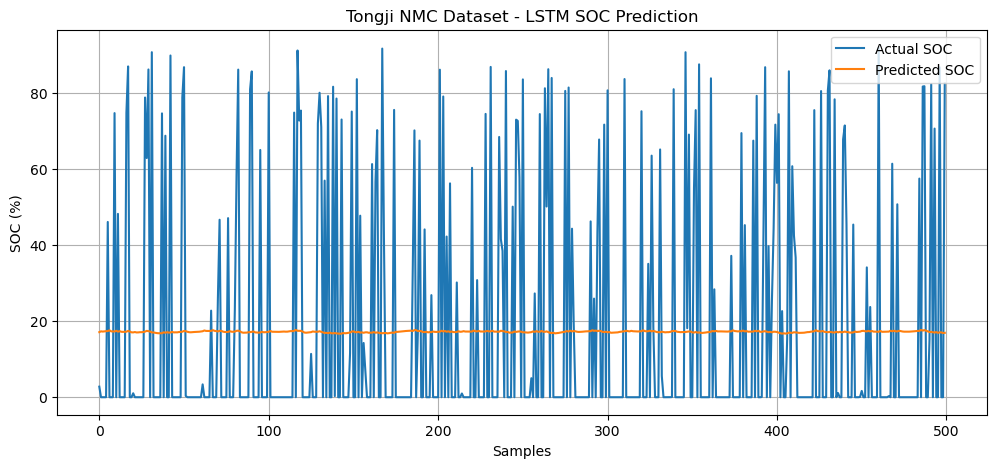

In [28]:
import matplotlib.pyplot as plt

y_test_inv = target_scaler.inverse_transform(y_test)
lstm_pred_inv = target_scaler.inverse_transform(lstm_pred)

plt.figure(figsize=(12,5))

plt.plot(
    y_test_inv[:500],
    label='Actual SOC'
)

plt.plot(
    lstm_pred_inv[:500],
    label='Predicted SOC'
)

plt.title('Tongji NMC Dataset - LSTM SOC Prediction')
plt.xlabel('Samples')
plt.ylabel('SOC (%)')
plt.legend()
plt.grid(True)

plt.show()

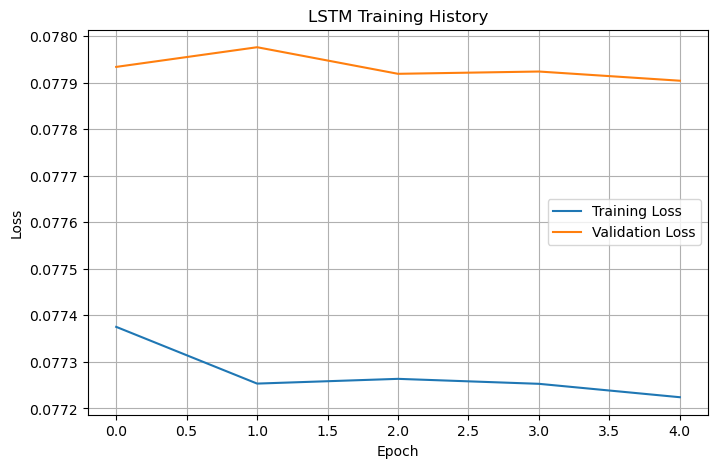

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

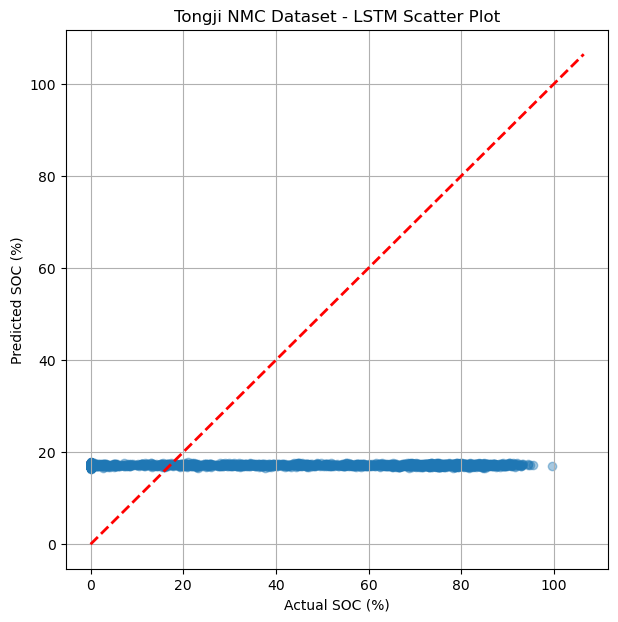

In [30]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_inv.flatten()[:5000],
    lstm_pred_inv.flatten()[:5000],
    alpha=0.4
)

min_val = min(
    y_test_inv.min(),
    lstm_pred_inv.min()
)

max_val = max(
    y_test_inv.max(),
    lstm_pred_inv.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual SOC (%)")
plt.ylabel("Predicted SOC (%)")
plt.title("Tongji NMC Dataset - LSTM Scatter Plot")

plt.grid(True)

plt.show()

# GRU Model Training

A Gated Recurrent Unit (GRU) network was developed to estimate SOC using Voltage and Current measurements from the Tongji NMC battery dataset.

The GRU architecture was selected due to its ability to efficiently capture temporal dependencies while maintaining a simpler structure than LSTM networks.

In [31]:
gru_model = Sequential([
    GRU(32, input_shape=(20,2)),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 59s 121ms/step - loss: 0.0782 - mae: 0.2273 - val_loss: 0.0780 - val_mae: 0.2270
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - loss: 0.0773 - mae: 0.2275 - val_loss: 0.0779 - val_mae: 0.2281
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - loss: 0.0772 - mae: 0.2274 - val_loss: 0.0779 - val_mae: 0.2309
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - loss: 0.0772 - mae: 0.2275 - val_loss: 0.0779 - val_mae: 0.2308
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - loss: 0.0772 - mae: 0.2275 - val_loss: 0.0780 - val_mae: 0.2241


In [32]:
gru_loss, gru_mae = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

gru_pred = gru_model.predict(X_test)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gru_pred
    )
)

print("GRU Results")
print("Loss :", gru_loss)
print("MAE  :", gru_mae)
print("RMSE :", gru_rmse)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step
GRU Results
Loss : 0.07771698385477066
MAE  : 0.22364532947540283
RMSE : 0.27877761879938795


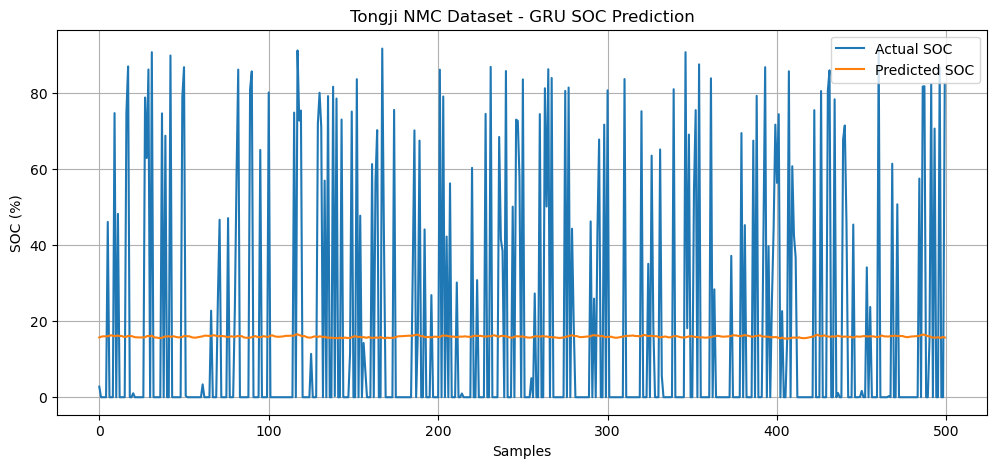

In [33]:
gru_pred_inv = target_scaler.inverse_transform(
    gru_pred
)

plt.figure(figsize=(12,5))

plt.plot(
    y_test_inv[:500],
    label='Actual SOC'
)

plt.plot(
    gru_pred_inv[:500],
    label='Predicted SOC'
)

plt.title('Tongji NMC Dataset - GRU SOC Prediction')
plt.xlabel('Samples')
plt.ylabel('SOC (%)')
plt.legend()
plt.grid(True)

plt.show()

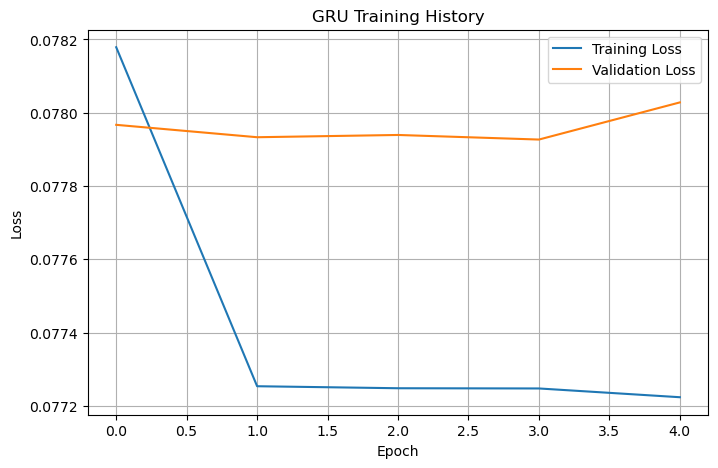

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    history_gru.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_gru.history['val_loss'],
    label='Validation Loss'
)

plt.title('GRU Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

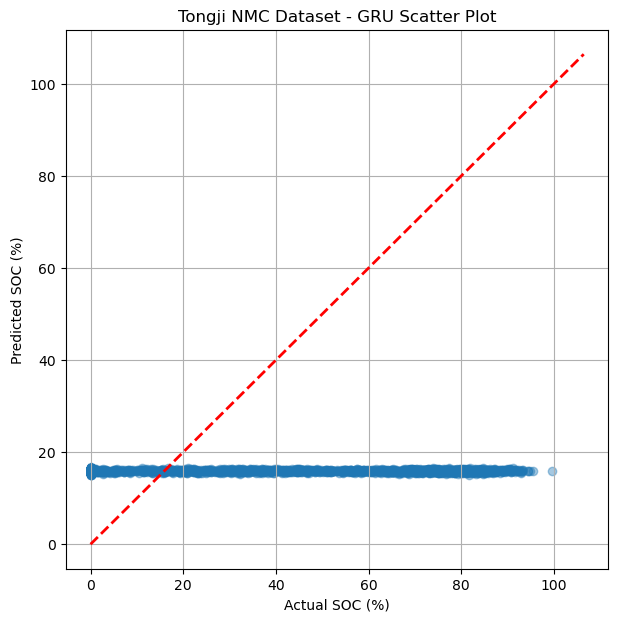

In [35]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_inv.flatten()[:5000],
    gru_pred_inv.flatten()[:5000],
    alpha=0.4
)

min_val = min(
    y_test_inv.min(),
    gru_pred_inv.min()
)

max_val = max(
    y_test_inv.max(),
    gru_pred_inv.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual SOC (%)")
plt.ylabel("Predicted SOC (%)")
plt.title("Tongji NMC Dataset - GRU Scatter Plot")

plt.grid(True)

plt.show()

## Tongji NMC Results

| Model | Loss | MAE | RMSE |
|---------|---------|---------|---------|
| LSTM | 0.07760 | 0.22916 | 0.27857 |
| GRU | 0.07772 | 0.22365 | 0.27878 |

### Performance Analysis

Both LSTM and GRU models were successfully trained on the Tongji NMC battery dataset using Voltage and Current measurements as input features.

The GRU model achieved a slightly lower MAE than the LSTM model, indicating improved SOC estimation performance. Although the RMSE values of both models were nearly identical, GRU demonstrated marginally better overall prediction accuracy.

The results indicate that recurrent neural networks can effectively capture the temporal behavior of NMC batteries and estimate SOC from operational measurements.